# CSCI450 Project 2
## **Playing Card Detection**


**Our Team:**

**- Lyudmyla Buhayenko**

**- Sergei Vorobev**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from skimage import io
import os
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
dataset_dir = '../Playing Cards.v3-original_raw-images.coco'
split_names = ['train', 'valid', 'test']
subsample_dir = '../subsamples'
os.makedirs(subsample_dir, exist_ok=True)

SEED = 42
random.seed(SEED)

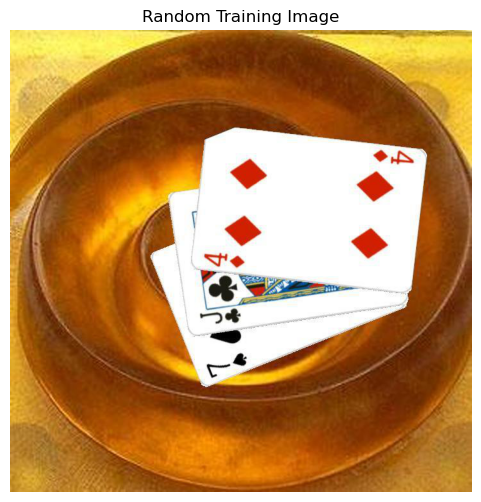

In [3]:
train_dir = os.path.join(dataset_dir, 'train')
images = os.listdir(train_dir)
random_image = random.choice(images)
img = io.imread(os.path.join(train_dir, random_image))

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title("Random Training Image")
plt.axis('off')
plt.show()

Fill out later: Object detection, what is YOLO, don't want to use a pretrained model so use our own approach. Explain the approach.

### Cropped Subsamples Creation

In [4]:
def get_random_background_crop(img, all_anns_for_image, crop_w, crop_h, max_attempts=50):
    img_h, img_w = img.shape[:2]
    for _ in range(max_attempts):
        rx = random.randint(0, img_w - crop_w)
        ry = random.randint(0, img_h - crop_h)

        overlap = False
        for ann in all_anns_for_image:
            ax = int(ann['bbox'][0])
            ay = int(ann['bbox'][1])
            aw = int(ann['bbox'][2])
            ah = int(ann['bbox'][3])
            if not (rx + crop_w < ax or rx > ax + aw or ry + crop_h < ay or ry > ay + ah):
                overlap = True
                break

        if not overlap:
            return img[ry:ry+crop_h, rx:rx+crop_w]
    return None

#### Use dataset annotations to save cropped class images

In [5]:
for split in split_names:
    os.makedirs(os.path.join(subsample_dir, split), exist_ok=True)
    with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
        data = json.load(f)

    images = {}
    for img in data['images']:
        images[img['id']] = img['file_name']

    categories = {}
    for cat in data['categories']:
        categories[cat['id']] = cat['name']

    annotations_by_image = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in annotations_by_image:
            annotations_by_image[img_id] = []
        annotations_by_image[img_id].append(ann)

    counter = 0
    bg_counter = 0

    for ann in data['annotations']:
        filename = images[ann['image_id']]
        class_name = categories[ann['category_id']]
        img = io.imread(os.path.join(dataset_dir, split, filename))

        x = int(ann['bbox'][0])
        y = int(ann['bbox'][1])
        w = int(ann['bbox'][2])
        h = int(ann['bbox'][3])

        crop = img[y:y+h, x:x+w]
        class_dir = os.path.join(subsample_dir, split, class_name)
        os.makedirs(class_dir, exist_ok=True)
        io.imsave(os.path.join(class_dir, f'{counter}.jpg'), crop)
        counter += 1

        all_anns_for_image = annotations_by_image[ann['image_id']]
        bg_crop = get_random_background_crop(img, all_anns_for_image, w, h)
        if bg_crop is not None:
            bg_dir = os.path.join(subsample_dir, split, 'background')
            os.makedirs(bg_dir, exist_ok=True)
            io.imsave(os.path.join(bg_dir, f'{bg_counter}.jpg'), bg_crop)
            bg_counter += 1

    print(f'{split}: saved {counter} card crops and {bg_counter} background crops')

train: saved 28280 card crops and 28280 background crops
valid: saved 8080 card crops and 8080 background crops
test: saved 4040 card crops and 4040 background crops


#### Limit the size of the negative class

In [6]:
for split in split_names:
    split_path = os.path.join(subsample_dir, split)
    
    class_counts = {}
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    
    non_bg_counts = []
    for cls, count in class_counts.items():
        if cls != 'background':
            non_bg_counts.append(count)
    
    avg = int(sum(non_bg_counts) / len(non_bg_counts))
    cap = avg * 5
    
    print(f"{split}: average class size={avg}, background cap={cap}, current background={class_counts['background']}")
    
    bg_path = os.path.join(split_path, 'background')
    bg_files = sorted(os.listdir(bg_path))
    if len(bg_files) > cap:
        to_delete = random.sample(bg_files, len(bg_files) - cap)
        for f in to_delete:
            os.remove(os.path.join(bg_path, f))
        print(f"{split}: trimmed background from {len(bg_files)} to {cap}")
    else:
        print(f"{split}: background already under cap")

train: average class size=543, background cap=2715, current background=28280
train: trimmed background from 28280 to 2715
valid: average class size=155, background cap=775, current background=8080
valid: trimmed background from 8080 to 775
test: average class size=77, background cap=385, current background=4040
test: trimmed background from 4040 to 385


#### Class Distribution

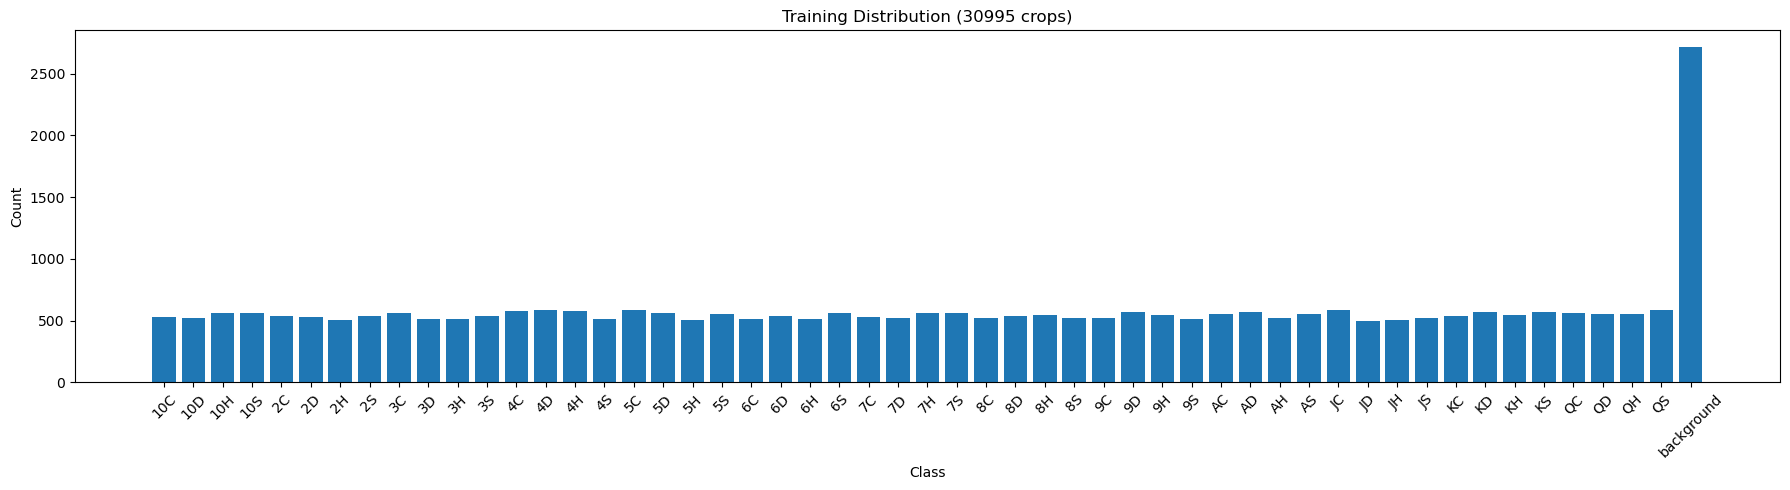

In [7]:
split_path = os.path.join(subsample_dir, 'train')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Training Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

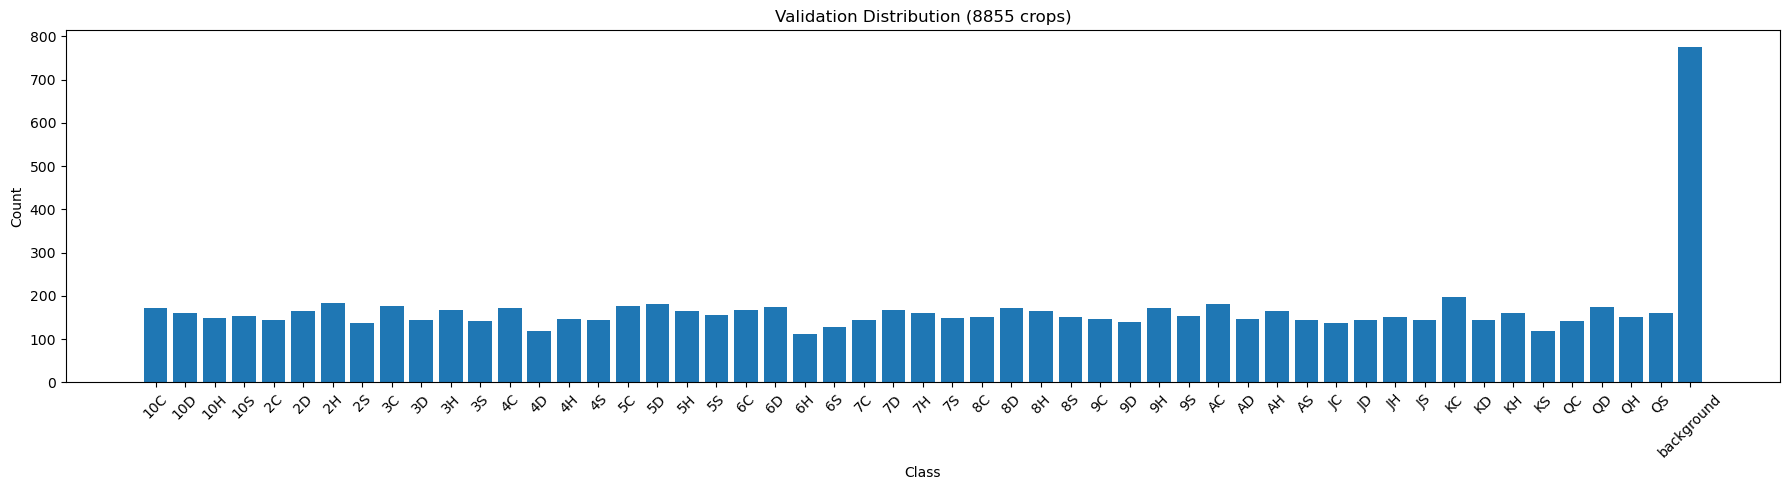

In [8]:
split_path = os.path.join(subsample_dir, 'valid')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Validation Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

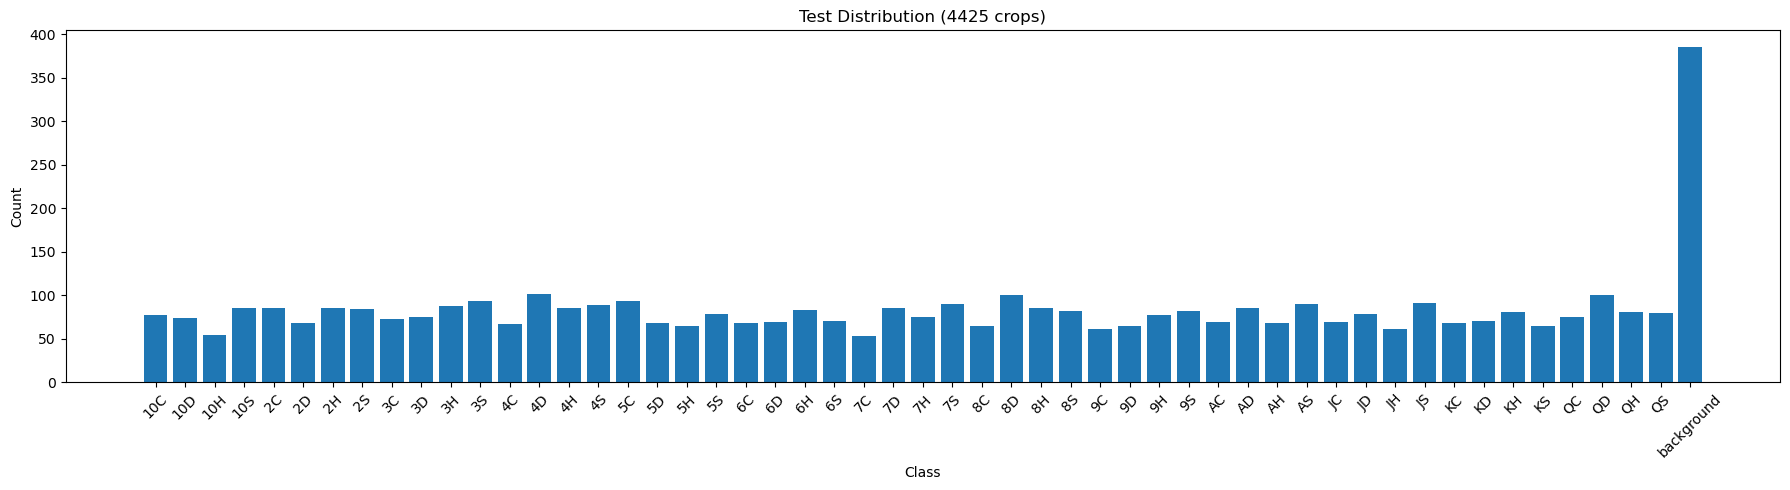

In [9]:
split_path = os.path.join(subsample_dir, 'test')

class_counts = {}
for class_name in sorted(os.listdir(split_path)):
    class_path = os.path.join(split_path, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

plt.figure(figsize=(18, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title(f'Test Distribution ({sum(class_counts.values())} crops)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### CNN Classification Model

In [10]:
dataset_dir = '../Playing Cards.v3-original_raw-images.coco'
widths = []
heights = []

for split in split_names:
    with open(os.path.join(dataset_dir, split, '_annotations.coco.json')) as f:
        data = json.load(f)

    for ann in data['annotations']:
        w = int(ann['bbox'][2])
        h = int(ann['bbox'][3])
        widths.append(w)
        heights.append(h)

print(f"Width --- min: {min(widths)}, max: {max(widths)}, avg: {int(sum(widths)/len(widths))}")
print(f"Height --- min: {min(heights)}, max: {max(heights)}, avg: {int(sum(heights)/len(heights))}")

Width --- min: 19, max: 83, avg: 46
Height --- min: 19, max: 83, avg: 46


### Card Detection